## Desafio: E-commerce & Demografia

**Contexto do desafio:**
Você recebeu uma demanda em uma vaga de estágio em dados: a diretoria está planejando a estratégia de expansão para o próximo semestre e quer entender melhor onde estão as maiores oportunidades. 

Sua primeira grande missão é analisar a nossa base histórica de clientes, cruzar com dados demográficos oficiais e descobrir *quais são as perspectivas de crescimento da empresa e para quais regiões devemos direcionar nossos esforços de marketing e logística?*



Importando as bibliotecas utilizadas no projeto:

In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns
from unidecode import unidecode
import plotly.express as px


### Um resumo breve sobre cada fonte de dados:

**Olist:**

Este é um conjunto de dados públicos de comércio eletrônico brasileiro de pedidos feitos na Olist Store. 

O conjunto de dados contém informações de 100 mil pedidos de 2016 a 2018 feitos em vários marketplaces no Brasil. Seus recursos permitem visualizar um pedido em múltiplas dimensões: desde status do pedido, preço, desempenho de pagamento e frete até localização do cliente, atributos do produto e finalmente avaliações escritas pelos clientes.

Também temos um conjunto de dados de geolocalização que reporta os CEPs brasileiros em coordenadas lat/lng.  

Estes são dados comerciais reais, foram anonimizados e as referências às empresas e parceiros no texto da revisão foram substituídas pelos nomes das grandes casas de Game of Thrones.

Atenções:
- Um pedido pode ter vários itens.

- Cada item pode ser entregue por um vendedor distinto.

- Todos os textos de identificação de lojas e parceiros foram substituídos pelos nomes das grandes casas de Game of Thrones.

**IBGE (Censo Demográfico 2022 - Tabela 4709):**

Este é um conjunto de dados demográficos oficiais e públicos do Brasil, extraído através da API do Sistema IBGE de Recuperação Automática (SIDRA).

O conjunto de dados contém a população residente atualizada de todos os 5.570 municípios brasileiros, apurada no último Censo Demográfico (2022). Seus recursos permitem cruzar o volume populacional de cada cidade com outras bases mercadológicas para entender a densidade demográfica, calcular taxas de penetração de mercado e descobrir o potencial de expansão em diferentes regiões do país.


Atenções:

- A API retorna o nome do município e a sigla do estado concatenados em uma única string (ex: "Curitiba (PR)").

- Os valores correspondentes à população residente chegam no formato de texto (string) e precisam ser convertidos para números inteiros (int) para permitir cálculos ou agregações.

- A primeira linha (índice 0) do retorno JSON da API contém os nomes das colunas e os metadados, enquanto os dados reais começam a partir da segunda linha.

- Diferenças na grafia (acentuação, hifens ou abreviações) podem gerar perdas ao cruzar com outras bases, sendo essencial uma etapa de limpeza e padronização (como a remoção de acentos e conversão para minúsculas).

### Importando os dados Olist:

**Estratégia de Ingestão - Base Olist:** Optei por realizar o download manual do dataset através do portal Kaggle e ler os arquivos localmente com pd.read_csv(). A extração programática direta pelo Python exigiria o uso da biblioteca kaggle e a exposição de tokens de autenticação pessoais (kaggle.json) no ambiente ou no repositório do projeto, o que fere as boas práticas de segurança da informação.

In [3]:
df_customers_bruto = pd.read_csv('dados/olist_customers_dataset.csv')
display(df_customers_bruto.head())

df_geolocations_bruto = pd.read_csv('dados/olist_geolocation_dataset.csv')
display(df_geolocations_bruto.head())

df_order_items_bruto = pd.read_csv('dados/olist_order_items_dataset.csv')
display(df_order_items_bruto.head())

df_order_payments_bruto = pd.read_csv('dados/olist_order_payments_dataset.csv')
display(df_order_payments_bruto.head())

df_order_reviews_bruto = pd.read_csv('dados/olist_order_reviews_dataset.csv')
display(df_order_reviews_bruto.head())

df_orders_bruto = pd.read_csv('dados/olist_orders_dataset.csv')
display(df_orders_bruto.head())

df_products_bruto = pd.read_csv('dados/olist_products_dataset.csv')
display(df_products_bruto.head())

df_sellers_bruto = pd.read_csv('dados/olist_sellers_dataset.csv')
display(df_sellers_bruto.head())

df_category_name_translation_bruto = pd.read_csv('dados/product_category_name_translation.csv')
display(df_category_name_translation_bruto.head())


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Importando os dados IBGE:

In [4]:
url_ibge = 'https://apisidra.ibge.gov.br/values/t/4709/n6/all/v/93/p/last'

response = requests.get(url_ibge)
if response.status_code == 200:
    dados_json = response.json()
    print(dados_json[1])
    
    # Transforma em DataFrame usando a linha 0 como nome das colunas e linha 1 como dados
    df_ibge_bruto = pd.DataFrame(dados_json[1:], columns=dados_json[0])
    
    print("Dados do IBGE carregados com sucesso!")
    display(df_ibge_bruto.head())
else:
    print("Falha na conexão. Código de status:", response.status_code)


{'NC': '6', 'NN': 'Município', 'MC': '45', 'MN': 'Pessoas', 'V': '21494', 'D1C': '1100015', 'D1N': "Alta Floresta D'Oeste - RO", 'D2C': '93', 'D2N': 'População residente', 'D3C': '2022', 'D3N': '2022'}
Dados do IBGE carregados com sucesso!


,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
1,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022
3,6,Município,45,Pessoas,86887,1100049,Cacoal - RO,93,População residente,2022,2022
4,6,Município,45,Pessoas,15890,1100056,Cerejeiras - RO,93,População residente,2022,2022


### Análise Exploratória (EDA)

Como vamos precisar unir as tabelas de clientes e pedidos + a de IBGE, vou fazer uma vistoria nessas três tabelas.
A ferramenta escolhida para fazer a limpeza dos dados foi o Pandas, por conta da minha afinidade com a ferramenta e seus métodos de limpeza mais otimizados e nativos da própria biblioteca.

Tabela customers:

In [5]:
display(df_customers_bruto.head())

print(f'A base de customers possui {df_customers_bruto.shape[0]} linhas e {df_customers_bruto.shape[1]} colunas.\n')

display(df_customers_bruto.info())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


A base de customers possui 99441 linhas e 5 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


None

- Não foram encontrados valores nulos nessa tabela.
- As cidades seguem um padrão de nome: letras minúsculas, sem acentos e com a sigla do estado separado em outra coluna (customer_state).

Tabela pedidos:

In [6]:
display(df_orders_bruto.head())

print(f'A base de orders possui {df_orders_bruto.shape[0]} linhas e {df_orders_bruto.shape[1]} colunas.\n')

display(df_orders_bruto.info())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


A base de orders possui 99441 linhas e 8 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


None

In [7]:
display(df_orders_bruto['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Já na tabela pedidos, o comportamento é diferente:
- Muitos pedidos acabam não sendo completos, cancelados ou perdidos, então nesses casos não temos o status de recebimento e outros dados relacionados a compras completas (order_status == 'delivered').

Como preciso dos dados de pedidos realizados, vou separar a base de dados:

In [8]:
df_orders_status_delivered = df_orders_bruto.query("order_status == 'delivered'").copy()
display(df_orders_status_delivered.head())

display(df_orders_status_delivered.info())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       96478 non-null  str  
 1   customer_id                    96478 non-null  str  
 2   order_status                   96478 non-null  str  
 3   order_purchase_timestamp       96478 non-null  str  
 4   order_approved_at              96464 non-null  str  
 5   order_delivered_carrier_date   96476 non-null  str  
 6   order_delivered_customer_date  96470 non-null  str  
 7   order_estimated_delivery_date  96478 non-null  str  
dtypes: str(8)
memory usage: 6.6 MB


None

Após separar apenas os pedidos entregues, foi observado que em algumas colunas (order_approved_at, order_delivered_carrier_date, order_delivered_customer_date) estão faltando dados, relacionado a datas de entrega. 

- A falta de dados sobre datas de entrega em bases de dados (missings) é um problema comum de qualidade de dados (master data) que afeta a logística e o varejo. Os motivos variam desde falhas humanas até limitações técnicas, como integração de sistemas e o momento em que a informação é registrada.

Como o objetivo do teste é ver o número total de entregas que cada cliente realizou, as datas incompletas não vão afetar os resultados.

Tabela IBGE

In [9]:
display(df_ibge_bruto.head())

print(f'A base do IBGE possui {df_ibge_bruto.shape[0]} linhas e {df_ibge_bruto.shape[1]} colunas.\n')

display(df_ibge_bruto.info())

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
1,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022
3,6,Município,45,Pessoas,86887,1100049,Cacoal - RO,93,População residente,2022,2022
4,6,Município,45,Pessoas,15890,1100056,Cerejeiras - RO,93,População residente,2022,2022


A base do IBGE possui 5570 linhas e 11 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NC      5570 non-null   str  
 1   NN      5570 non-null   str  
 2   MC      5570 non-null   str  
 3   MN      5570 non-null   str  
 4   V       5570 non-null   str  
 5   D1C     5570 non-null   str  
 6   D1N     5570 non-null   str  
 7   D2C     5570 non-null   str  
 8   D2N     5570 non-null   str  
 9   D3C     5570 non-null   str  
 10  D3N     5570 non-null   str  
dtypes: str(11)
memory usage: 478.8 KB


None

Seguindo o padrão da planilha de customers, os nomes das cidades precisam estar no mesmo padrão para que a junção de tabelas funcione:

In [10]:
df_ibge_clean = df_ibge_bruto.copy()

df_ibge_clean['D1N'] = df_ibge_clean['D1N'].apply(unidecode)

display(df_ibge_clean.head())

df_ibge_clean['customer_city'] = df_ibge_clean['D1N'].str.split(' - ').str[0]

df_ibge_clean['customer_city'] = df_ibge_clean['customer_city'].str.lower()

df_ibge_clean['customer_state'] = df_ibge_clean['D1N'].str.split(' - ').str[1]

df_ibge_clean['customer_state'] = df_ibge_clean['customer_state'].str.upper()

display(df_ibge_clean[['D1N', 'customer_city', 'customer_state']].head())

display(df_ibge_clean.info())


,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
1,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022
3,6,Município,45,Pessoas,86887,1100049,Cacoal - RO,93,População residente,2022,2022
4,6,Município,45,Pessoas,15890,1100056,Cerejeiras - RO,93,População residente,2022,2022


,D1N,customer_city,customer_state
0,Alta Floresta D'Oeste - RO,alta floresta d'oeste,RO
1,Ariquemes - RO,ariquemes,RO
2,Cabixi - RO,cabixi,RO
3,Cacoal - RO,cacoal,RO
4,Cerejeiras - RO,cerejeiras,RO


<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NC              5570 non-null   str   
 1   NN              5570 non-null   str   
 2   MC              5570 non-null   str   
 3   MN              5570 non-null   str   
 4   V               5570 non-null   str   
 5   D1C             5570 non-null   str   
 6   D1N             5570 non-null   str   
 7   D2C             5570 non-null   str   
 8   D2N             5570 non-null   str   
 9   D3C             5570 non-null   str   
 10  D3N             5570 non-null   str   
 11  customer_city   5570 non-null   object
 12  customer_state  5570 non-null   object
dtypes: object(2), str(11)
memory usage: 565.8+ KB


None

In [11]:
df_ibge_clean['V'] = df_ibge_clean['V'].astype(int)

display(df_ibge_clean.info())


<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NC              5570 non-null   str   
 1   NN              5570 non-null   str   
 2   MC              5570 non-null   str   
 3   MN              5570 non-null   str   
 4   V               5570 non-null   int64 
 5   D1C             5570 non-null   str   
 6   D1N             5570 non-null   str   
 7   D2C             5570 non-null   str   
 8   D2N             5570 non-null   str   
 9   D3C             5570 non-null   str   
 10  D3N             5570 non-null   str   
 11  customer_city   5570 non-null   object
 12  customer_state  5570 non-null   object
dtypes: int64(1), object(2), str(10)
memory usage: 565.8+ KB


None

Criando a base unificada:

In [12]:
query = """
    SELECT 
        c.customer_city AS cidade,
        c.customer_state AS estado,
        i.V AS populacao,
        COUNT(DISTINCT c.customer_unique_id) AS total_clientes_unicos,
        COUNT(DISTINCT o.order_id) AS total_pedidos
    FROM df_customers_bruto AS c
    
    -- 1. Primeiro cruzamos clientes com os pedidos entregues
    INNER JOIN df_orders_status_delivered AS o 
        ON c.customer_id = o.customer_id
        
    -- 2. Depois cruzamos o resultado com o IBGE usando Cidade E Estado
    INNER JOIN df_ibge_clean AS i 
        ON c.customer_city = i.customer_city 
        AND c.customer_state = i.customer_state
        
    GROUP BY 
        c.customer_city,
        c.customer_state,
        i.V
    ORDER BY 
        total_pedidos DESC
"""

df_customers_ibge = duckdb.query(query).df()

print(f'A base resultante do cruzamento possui {df_customers_ibge.shape[0]} linhas e {df_customers_ibge.shape[1]} colunas.\n')
display(df_customers_ibge.info())

A base resultante do cruzamento possui 3985 linhas e 5 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 3985 entries, 0 to 3984
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   cidade                 3985 non-null   str  
 1   estado                 3985 non-null   str  
 2   populacao              3985 non-null   int64
 3   total_clientes_unicos  3985 non-null   int64
 4   total_pedidos          3985 non-null   int64
dtypes: int64(3), str(2)
memory usage: 155.8 KB


None

Como vimos acima, a base do IBGE possui 5570 linhas preenchidas, ou seja 5570 cidades cadastradas. 

Quando realizei o INNER JOIN (juntar as bases pelos dados que temos em comum) percebi que a nova base só possui 3985 linhas, sinalizando que algumas cidades ficaram de fora dessa junção.

Irei analisar agora utilizando o LEFT JOIN (retorna todos os dados da tabela customers, e se não tiver vínculo com a tabela IBGE, retorna NULL) e filtrar pelas cidades que estiverem como resultado NULL.

In [13]:
query_tarefa_3 = """
    SELECT DISTINCT 
        c.customer_city AS cidade_olist, 
        c.customer_state AS estado_olist
    FROM df_customers_bruto AS c
    LEFT JOIN df_ibge_clean AS i 
        ON c.customer_city = i.customer_city 
        AND c.customer_state = i.customer_state
    WHERE i.customer_city IS NULL
    ORDER BY estado_olist, cidade_olist
"""

df_cidades_fora = duckdb.query(query_tarefa_3).df()

print(f"Total de cidades da Olist não encontradas no IBGE: {len(df_cidades_fora)}")
display(df_cidades_fora.head(15))


Total de cidades da Olist não encontradas no IBGE: 295


,cidade_olist,estado_olist
0,luziapolis,AL
1,pau d'arco,AL
2,abrantes,BA
3,arembepe,BA
4,aribice,BA
5,arraial d ajuda,BA
6,arraial d'ajuda,BA
7,barra do tarrachil,BA
8,caldas do jorro,BA
9,carnaiba do sertao,BA


Existem diversos motivos para essas cidades não serem encontradas na base de dados do IBGE, como:
- Erros de digitação
- Mudanças de nomes de municípios ou cidades que a Olist tem, mas o IBGE não reconhece como munucípio oficial.

Esses erros são muito comuns no preenchimento manual dessas informações na hora da compra.
Para um projeto em produção, o ideal seria ter uma validação de CEP no front-end, para forçar o preenchimento automático e padronizado do nome da cidade e estado, eliminando esse problema raiz.

In [14]:
query_tarefa_4 = """
    SELECT
        cidade,
        estado,
        populacao,
        total_clientes_unicos,
        -- Multiplicamos por 100.0 para garantir as casas decimais
        (total_clientes_unicos * 100.0 / populacao) AS penetracao
    FROM df_customers_ibge
    WHERE populacao > 200000
    ORDER BY penetracao ASC
"""

df_penetracao_estado = duckdb.query(query_tarefa_4).df()
display(df_penetracao_estado)

,cidade,estado,populacao,total_clientes_unicos,penetracao
0,sao jose de ribamar,MA,244579,14,0.005724
1,manaus,AM,2063689,132,0.006396
2,maraba,PA,266533,22,0.008254
3,parauapebas,PA,267836,24,0.008961
4,boa vista,RR,413486,39,0.009432
...,...,...,...,...,...
147,jundiai,SP,443221,532,0.120030
148,sao paulo,SP,11451999,14528,0.126860
149,barueri,SP,316473,406,0.128289
150,santos,SP,418608,680,0.162443


/tmp/ipykernel_284323/522082815.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


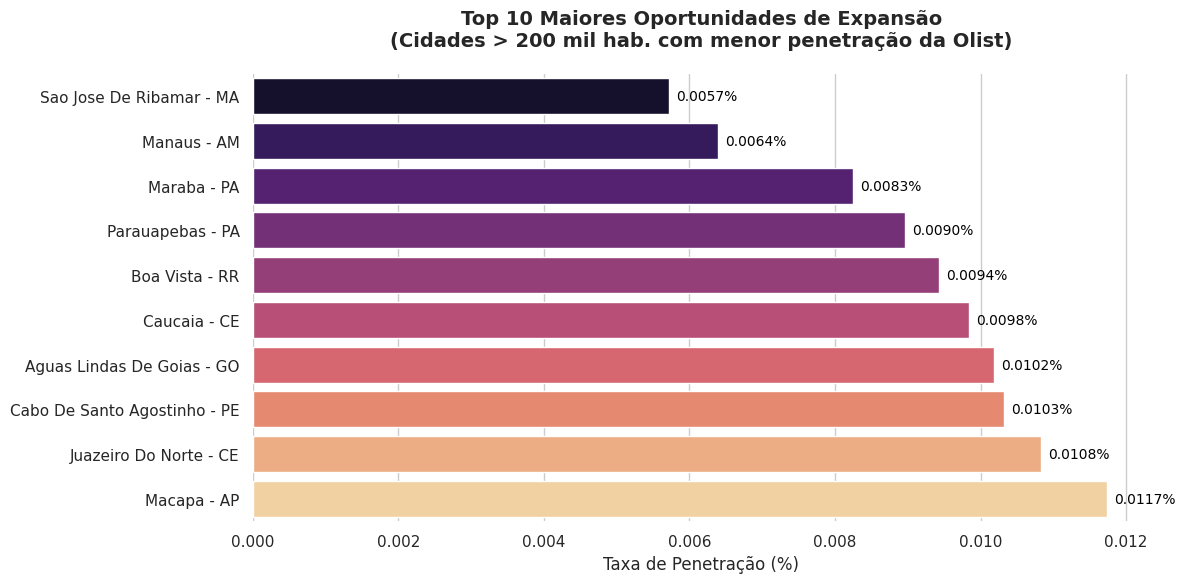

In [15]:
df_top10_oportunidades = df_penetracao_estado.head(10).copy()

df_top10_oportunidades['cidade_uf'] = df_top10_oportunidades['cidade'].str.title() + ' - ' + df_top10_oportunidades['estado']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

grafico = sns.barplot(
    data=df_top10_oportunidades,
    x='penetracao',
    y='cidade_uf',
    palette='magma'
)

plt.title('Top 10 Maiores Oportunidades de Expansão\n(Cidades > 200 mil hab. com menor penetração da Olist)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Taxa de Penetração (%)', fontsize=12)
plt.ylabel('', fontsize=12)

for p in grafico.patches:
    grafico.annotate(f'{p.get_width():.4f}%', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', 
                     xytext=(5, 0), textcoords='offset points',
                     fontsize=10, color='black')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Gráfico representando as cidades com mais de 200 mil habitantes com pouca penetração (poucos clientes).

Agora para o próximo passo, farei um mapa interativo do Brasil com o volume de clientes em cada cidade/estado, utilizando a base de dados de geolocalização:

In [16]:
display(df_geolocations_bruto.head())

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Juntar as geolocalizações com a quantidade de clientes daquela cidade:

In [17]:
query_mapa = """
    WITH geo_unica AS (
        SELECT 
            geolocation_zip_code_prefix AS cep,
            AVG(geolocation_lat) AS lat,
            AVG(geolocation_lng) AS lng
        FROM df_geolocations_bruto
        GROUP BY geolocation_zip_code_prefix
    )
    
    SELECT 
        c.customer_city AS cidade,
        c.customer_state AS estado,
        g.lat,
        g.lng,
        COUNT(c.customer_unique_id) AS total_clientes
    FROM df_customers_bruto AS c
    INNER JOIN geo_unica AS g 
        ON c.customer_zip_code_prefix = g.cep
    GROUP BY 
        cidade, estado, lat, lng
"""

df_mapa = duckdb.query(query_mapa).df()
display(df_mapa.head())

,cidade,estado,lat,lng,total_clientes
0,pelotas,RS,-31.765483,-52.320484,1
1,santo antonio das missoes,RS,-28.507734,-55.231599,4
2,sao paulo,SP,-23.525481,-46.641595,3
3,sao paulo,SP,-23.472381,-46.681668,1
4,sao paulo,SP,-23.537065,-46.615082,2


Construção do gráfico utilizando a biblioteca plotly e o modelo de mapa de pontos (mapbox):

In [18]:
fig = px.scatter_map(
    df_mapa, 
    lat="lat", 
    lon="lng", 
    hover_name="cidade", 
    hover_data={"estado": True, "total_clientes": True, "lat": False, "lng": False},
    size="total_clientes", 
    color="total_clientes",
    title="Distribuição Geográfica dos Clientes Olist por Cidade",
    zoom=4, 
    map_style="open-street-map"

)

fig.show()

O Mapa Geográfico nos mostra a situação geral da Olist no Brasil, indicando que a sua maior concentração está no Sul e Sudeste (com destaque para São Paulo e Rio de Janeiro).

Já o gráfico de penetração anterior, indica que os estados com menor penetração e melhores cenários para investimentos estão no Norte/Nordeste do Brasil.

Seguindo o mapa geográfico com todos os clientes, também escolhi trazer um gráfico de linhas representando a sazonalidade dos produtos durante o ano:

In [19]:
df_orders_status_delivered['order_purchase_timestamp'] = pd.to_datetime(df_orders_status_delivered['order_purchase_timestamp'])
display(df_orders_status_delivered.head())



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Formatando a coluna de timestamp para o formato (ano-mês) para melhor visualização no gráfico, junto com a soma de vendas naquele mês:

In [20]:
df_orders_status_delivered['ano_mes'] = df_orders_status_delivered['order_purchase_timestamp'].dt.to_period('M')

vendas_por_mes = df_orders_status_delivered.groupby('ano_mes')['order_id'].count().reset_index()
display(vendas_por_mes.head())


,ano_mes,order_id
0,2016-09,1
1,2016-10,265
2,2016-12,1
3,2017-01,750
4,2017-02,1653


Plotagem do gráfico:

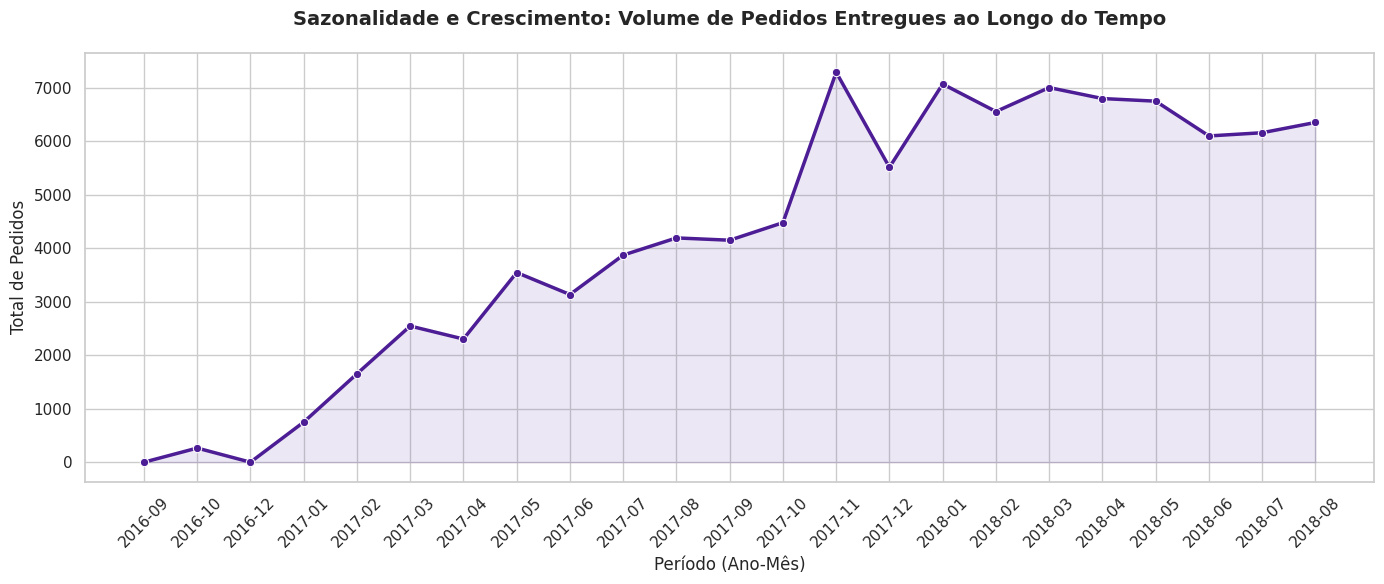

In [21]:
vendas_por_mes['ano_mes'] = vendas_por_mes['ano_mes'].astype(str)

plt.figure(figsize=(14, 6))

grafico_linha = sns.lineplot(
    data=vendas_por_mes,
    x='ano_mes',
    y='order_id',
    marker='o',        
    color='#4c1d95',     
    linewidth=2.5
)

plt.fill_between(vendas_por_mes['ano_mes'], vendas_por_mes['order_id'], color='#4c1d95', alpha=0.1)

plt.title('Sazonalidade e Crescimento: Volume de Pedidos Entregues ao Longo do Tempo', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Período (Ano-Mês)', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

O projeto nos deu uma boa visualização da distribuição de clientes da Olist pelo Brasil e possíveis regiões de melhorias. Para os próximos passos, podemos utilizar como base o gráfico de linha acima, para fazer uma análise profunda nos picos e quedas dos produtos em cada mês, para entender melhor por que em alguns meses tivemos um pico maior (novembro - 2017) e logo no próximo mês uma queda (dezembro - 2017) e por quê em 2018 mantemos um fluxo contínuo alto de vendas.

**Análise isolada do consumidor:**
Já mapeamos onde estão as oportunidades e quando as pessoas mais compram. Agora quero trazer uma visualização do que os clientes procuram

In [32]:
copia_order_payments = df_order_payments_bruto.copy()
soma_pagamentos = copia_order_payments['payment_type'].value_counts().reset_index()

soma_pagamentos = soma_pagamentos[soma_pagamentos['payment_type'] != 'not_defined']

soma_pagamentos.rename(columns={'payment_type': 'Tipo de Pagamento', 'count': 'Quantidade'}, inplace=True)

metodos_pagamento = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de Débito',
    'not_defined': 'Não Definido'
}

soma_pagamentos['Tipo de Pagamento'] = soma_pagamentos['Tipo de Pagamento'].map(metodos_pagamento)
display(soma_pagamentos.head())



,Tipo de Pagamento,Quantidade
0,Cartão de Crédito,76795
1,Boleto,19784
2,Voucher,5775
3,Cartão de Débito,1529


/tmp/ipykernel_284323/2671284465.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




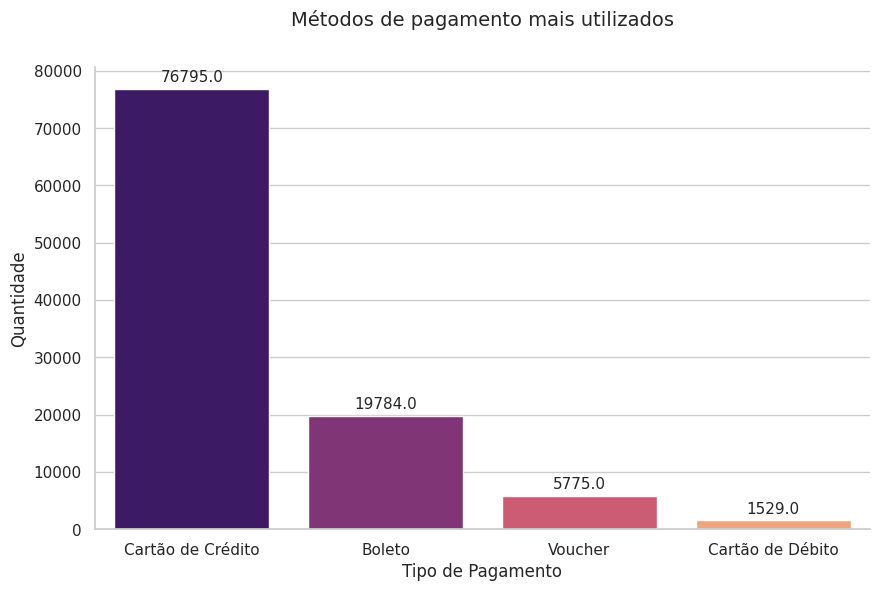

In [31]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tipo de Pagamento', y='Quantidade', data=soma_pagamentos, palette='magma')

plt.title('Métodos de pagamento mais utilizados', fontsize=14, pad=30)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

sns.despine()
plt.show()

Descobrir a preferência de pagamento (Cartão de Crédito x Boleto) ajuda a diretoria a negociar melhores taxas com as adquirentes e a prever o índice de cancelamento por boletos não pagos.

In [41]:
df_products_bruto.head()
df_order_items_bruto.head()

query_analise_produtos = """
    SELECT
        p.product_category_name AS categoria,
        COUNT(DISTINCT oi.order_id) AS total_pedidos,
        SUM(oi.price) AS receita_total
    FROM df_order_items_bruto AS oi
    INNER JOIN df_products_bruto AS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY total_pedidos DESC
    LIMIT 10
"""
df_analise_produtos = duckdb.query(query_analise_produtos).df()
display(df_analise_produtos.head(10))
display(df_analise_produtos.info())


,categoria,total_pedidos,receita_total
0,cama_mesa_banho,9417,1036988.68
1,beleza_saude,8836,1258681.34
2,esporte_lazer,7720,988048.97
3,informatica_acessorios,6689,911954.32
4,moveis_decoracao,6449,729762.49
5,utilidades_domesticas,5884,632248.66
6,relogios_presentes,5624,1205005.68
7,telefonia,4199,323667.53
8,automotivo,3897,592720.11
9,brinquedos,3886,483946.60


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   categoria      10 non-null     str    
 1   total_pedidos  10 non-null     int64  
 2   receita_total  10 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 372.0 bytes


None

/tmp/ipykernel_284323/4285005708.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




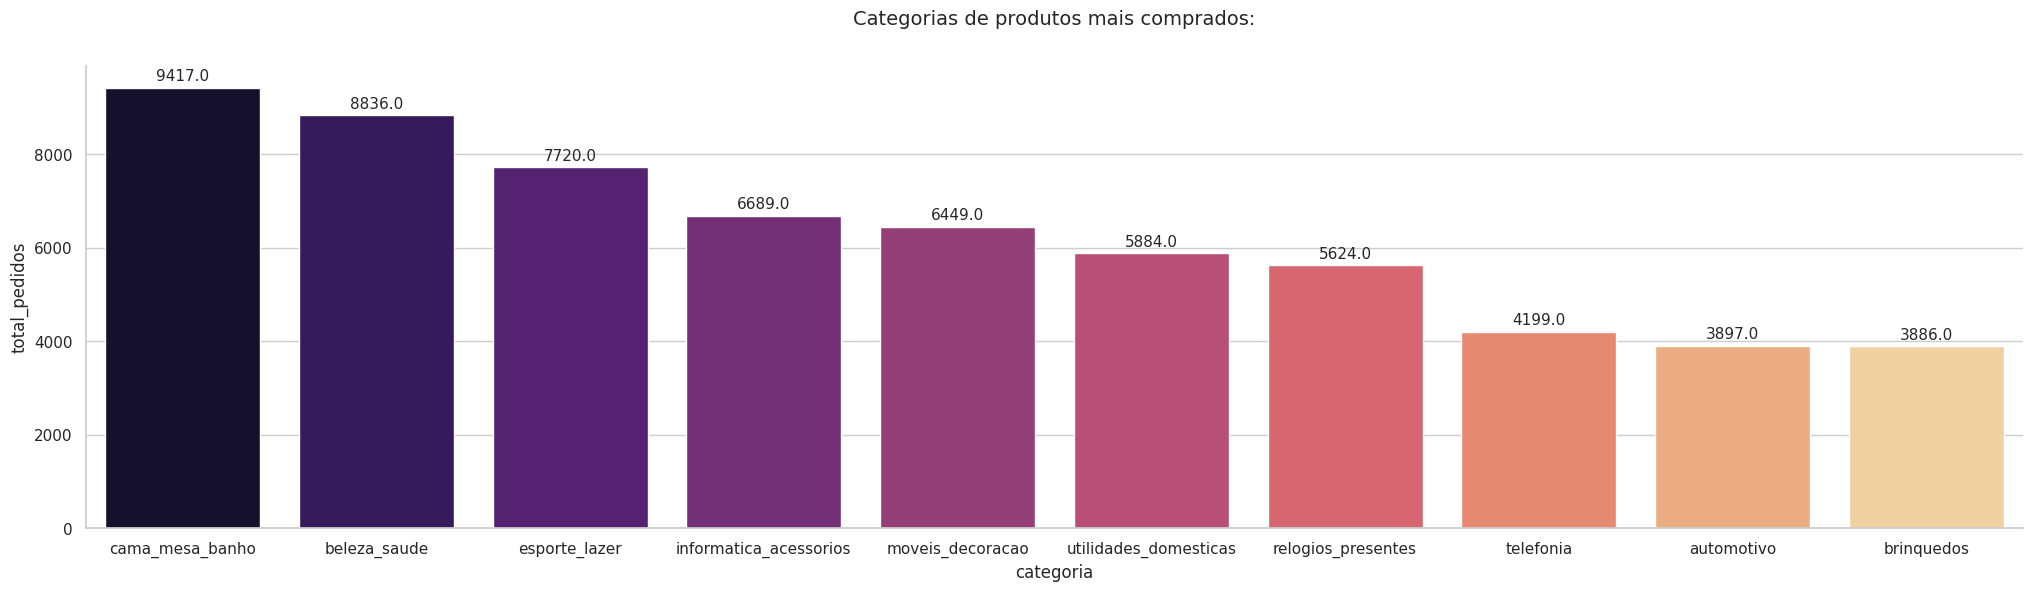

In [39]:
plt.figure(figsize=(25,6))
ax = sns.barplot(x='categoria', y='total_pedidos', data=df_analise_produtos, palette='magma')

plt.title('Categorias de produtos mais comprados:', fontsize=14, pad=30)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

sns.despine()
plt.show()

Além disso, cruzando as regiões de expansão com os dados de preferências de produtos e métodos de pagamento, temos um mapa completo para direcionar campanhas de marketing altamente personalizadas, com maior chance de conversão (focando em pagamentos instantâneos) e menor custo de aquisição (CAC).